In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast.core import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, TimesNet
from neuralforecast.losses.numpy import mae, mse
from pathlib import Path

In [21]:
df = pd.read_csv('D:\Developer\BGformer\data\OhioT1DM\glucose_value_540_training.csv')
df['unique_id'] = 'OT'
df['y'] = df['0']

# maxlen = 0
# for i, row in enumerate(df.iterrows()):
#     if len(row[1]) > maxlen:
#         maxlen = len(row[1])

# print(maxlen)

df['ds'] = pd.to_datetime(df['Unnamed: 0'])
df = df.drop('Unnamed: 0', axis=1)
print(len(df))
df = df.dropna(axis=0)
print(len(df))

print(df.head())

11947
11947
    0 unique_id   y                  ds
0  76        OT  76 2027-05-19 11:36:29
1  72        OT  72 2027-05-19 11:41:29
2  68        OT  68 2027-05-19 11:46:29
3  65        OT  65 2027-05-19 11:51:29
4  63        OT  63 2027-05-19 11:56:29


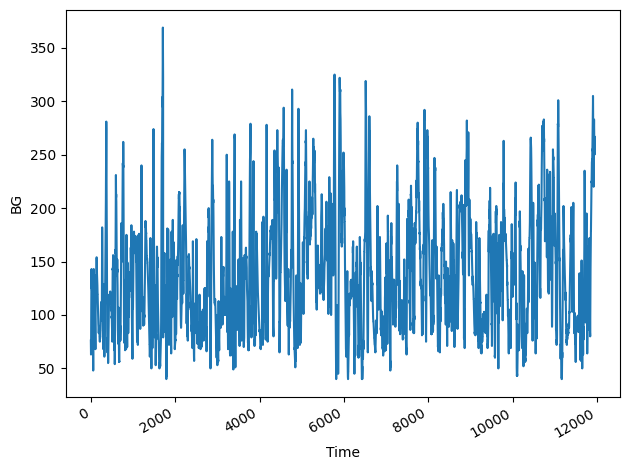

In [19]:
fig, ax = plt.subplots()

ax.plot(df['y'])
ax.set_xlabel('Time')
ax.set_ylabel('BG')

fig.autofmt_xdate()
plt.tight_layout()
# plt.savefig("img_0.png")
plt.show()

In [26]:
horizon=96

models = [NHITS(h=horizon,
               input_size=5*horizon,
               max_steps=50),
         NBEATS(h=horizon,
               input_size=5*horizon,
               max_steps=50),
      #    TimesNet(h=horizon,
      #            input_size=5*horizon,
      #            max_steps=50)
                 ]


nf = NeuralForecast(models=models, freq='H')
preds_df = nf.cross_validation(df=df, step_size=horizon, n_windows=4)

preds_df.head()

Seed set to 1
Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,cutoff,NHITS,NBEATS,0,y
0,OT,2027-06-18 00:56:44,2027-06-17 23:56:44,99.782860,94.000725,NaN,NaN
1,OT,2027-06-18 01:56:44,2027-06-17 23:56:44,100.073982,100.202644,NaN,NaN
2,OT,2027-06-18 02:56:44,2027-06-17 23:56:44,101.850800,103.438560,NaN,NaN
3,OT,2027-06-18 03:56:44,2027-06-17 23:56:44,102.997650,104.569626,NaN,NaN
4,OT,2027-06-18 04:56:44,2027-06-17 23:56:44,104.082413,105.278717,NaN,NaN


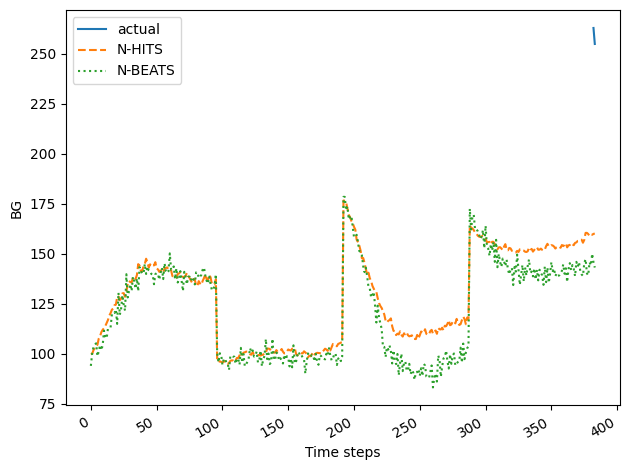

In [27]:
fig, ax = plt.subplots()

ax.plot(preds_df['y'], label='actual')
ax.plot(preds_df['NHITS'], label='N-HITS', ls='--')
ax.plot(preds_df['NBEATS'], label='N-BEATS', ls=':')
# ax.plot(preds_df['TimesNet'], label='TimesNet', ls='-.')

ax.legend(loc='best')
ax.set_xlabel('Time steps')
ax.set_ylabel('BG')

fig.autofmt_xdate()
# plt.ylim(-0.001, 0.001)
plt.tight_layout()
plt.savefig('out.png')

In [6]:
data = {'N-HiTS': [mae(preds_df['NHITS'], preds_df['y']), mse(preds_df['NHITS'], preds_df['y'])],
       'N-BEATS': [mae(preds_df['NBEATS'], preds_df['y']), mse(preds_df['NBEATS'], preds_df['y'])],
       'TimesNet': [mae(preds_df['TimesNet'], preds_df['y']), mse(preds_df['TimesNet'], preds_df['y'])]}

metrics_df = pd.DataFrame(data=data)
metrics_df.index = ['mae', 'mse']

metrics_df.style.highlight_min(color='lightgreen', axis=1)
metrics_df

,N-HiTS,N-BEATS,TimesNet
mae,2.840618e-04,0.002170,1.539884e-04
mse,1.308919e-07,0.000009,4.084646e-08
